<a href="https://colab.research.google.com/github/Akillesh-Suresh/IT480-FA26/blob/main/Lab1/Assignment1_hyperparameter_tuning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Assignment 1: Hyperparameter Tuning and Fixing Overfitting



### PART A

In [ ]:
# Import libraries for data handling, visualization, machine learning, and evaluation

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay

In [ ]:
# Create graphs for comparing training and validation performance

def plot_history(history, title, show_accuracy=False):
    if show_accuracy:
        fig, axes = plt.subplots(1, 2, figsize=(11, 4))


        axes[0].plot(history.history["loss"], label="Training Loss")
        axes[0].plot(history.history["val_loss"], label="Validation Loss")
        axes[0].set_xlabel("Epoch")
        axes[0].set_ylabel("Loss")
        axes[0].legend()
        axes[0].set_title(title + " -- Loss")

        axes[1].plot(history.history["accuracy"], label="Training Accuracy")
        axes[1].plot(history.history["val_accuracy"], label="Validation Accuracy")
        axes[1].set_xlabel("Epoch")
        axes[1].set_ylabel("Accuracy")
        axes[1].legend()
        axes[1].set_title(title + " -- Accuracy")

        plt.tight_layout()
        plt.show()

In [ ]:
# Load the red wine quality dataset from OpenML

wine = fetch_openml(
    name="wine-quality-red",
    version=1,
    as_frame=True,
    parser="auto"
)

df3 = wine.frame

# Display the dataset size and original quality class counts

print(df3.shape)
print(df3["class"].astype(int).value_counts().sort_index())

(1599, 12)
class
3     10
4     53
5    681
6    638
7    199
8     18
Name: count, dtype: int64


In [ ]:
# Convert the original wine quality scores into Low, Medium, and High classes

def bucket_quality(q):
    q = int(q)

    if q <= 5:
        return 0
    elif q == 6:
        return 1
    else:
        return 2

df3["quality_band"] = df3["class"].apply(bucket_quality)

# Display the number of samples in each new class

print(df3["quality_band"].value_counts().sort_index())

quality_band
0    744
1    638
2    217
Name: count, dtype: int64


In [ ]:
# Separate the input features from the target labels

X3 = df3.drop(columns=["class", "quality_band"]).values.astype(float)
y3 = df3["quality_band"].values.astype(int)

# Split the dataset into training and testing sets
X3_train, X3_test, y3_train, y3_test = train_test_split(
    X3,
    y3,
    test_size=0.2,
    random_state=42,
    stratify=y3
)

# Standardize the features using the training data
x3_scaler = StandardScaler()

X3_train_scaled = x3_scaler.fit_transform(X3_train)
X3_test_scaled = x3_scaler.transform(X3_test)

In [ ]:
# Find the number of output classes

n_classes = len(np.unique(y3))

# Build the original baseline neural network
model_multi = tf.keras.Sequential([
    tf.keras.Input(shape=(X3_train_scaled.shape[1],)),
    tf.keras.layers.Dense(64, activation="relu"),
    tf.keras.layers.Dense(32, activation="relu"),
    tf.keras.layers.Dense(n_classes, activation="softmax")
])

# Compile the model for multiclass classification
model_multi.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

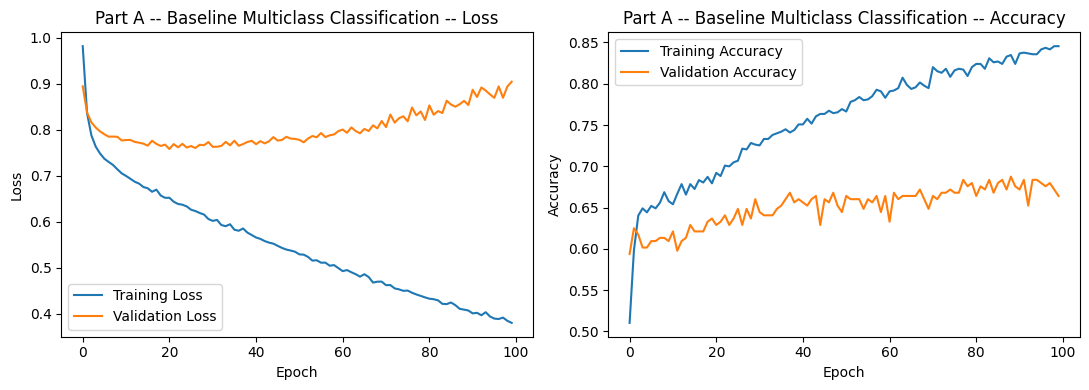

In [ ]:
# Train the baseline model using 20% of the training data for validation

history_multi = model_multi.fit(
    X3_train_scaled,
    y3_train,
    validation_split=0.2,
    epochs=100,
    batch_size=32,
    verbose=0
)

# Plot the training and validation curves to check for overfitting
plot_history(
    history_multi,
    "Part A -- Baseline Multiclass Classification",
    show_accuracy=True
)

10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
Baseline Test Accuracy: 0.709


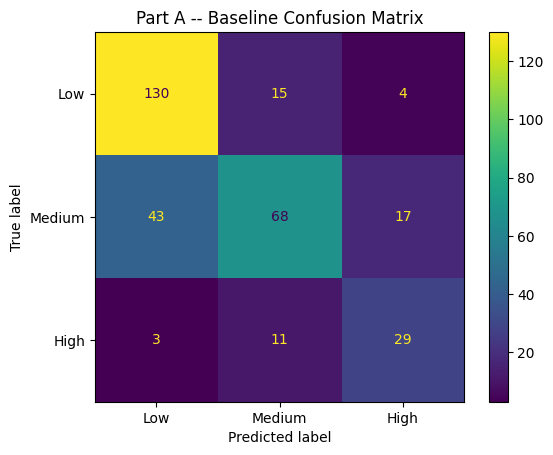

In [ ]:
# Make predictions on the test set

multi_probs = model_multi.predict(X3_test_scaled)
multi_preds = np.argmax(multi_probs, axis=1)

# Calculate the baseline test accuracy
acc_multi = accuracy_score(y3_test, multi_preds)

print(f"Baseline Test Accuracy: {acc_multi:.3f}")

# Create and display the baseline confusion matrix
cm3 = confusion_matrix(y3_test, multi_preds)

ConfusionMatrixDisplay(
    cm3,
    display_labels=["Low", "Medium", "High"]
).plot()

plt.title("Part A -- Baseline Confusion Matrix")
plt.show()

The original baseline model had a test accuracy of approximately 69.7%. The model showed overfitting because training loss continued to decrease throughout training, while validation loss stopped improving around 25–35 epochs and then began to increase. The gap between training and validation loss continued to grow as training continued, showing that the model was learning the training data better without improving its performance on validation data.

### PART B

In [ ]:
# Install Keras Tuner for hyperparameter tuning

!pip install keras-tuner --quiet

In [ ]:
# Import Keras Tuner

import keras_tuner as kt

In [ ]:
# Build a model that allows Keras Tuner to test different hyperparameters

def build_model(hp):
    model = tf.keras.Sequential([
        tf.keras.Input(shape=(X3_train_scaled.shape[1],)),

        # Tune the number of neurons in the first hidden layer
        tf.keras.layers.Dense(
            units=hp.Int("units_1", min_value=32, max_value=128, step=32),
            activation="relu"
        ),

        # Tune the number of neurons in the second hidden layer
        tf.keras.layers.Dense(
            units=hp.Int("units_2", min_value=16, max_value=64, step=16),
            activation="relu"
        ),


        tf.keras.layers.Dense(n_classes, activation="softmax")
    ])

    # Tune the learning rate used by the Adam optimizer
    learning_rate = hp.Choice(
        "learning_rate",
        values=[0.001, 0.0005, 0.0001]
    )

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=learning_rate),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )

    return model

In [ ]:
# Set up Random Search to find the best hyperparameter configuration

tuner = kt.RandomSearch(
    build_model,
    objective="val_accuracy",
    max_trials=10,
    executions_per_trial=1,
    directory="keras_tuner_results",
    project_name="wine_quality_tuning"
)

Reloading Tuner from keras_tuner_results/wine_quality_tuning/tuner0.json


In [ ]:
# Search for the best hyperparameters using only the training data

tuner.search(
    X3_train_scaled,
    y3_train,
    validation_split=0.2,
    epochs=50,
    batch_size=32,
    verbose=1
)

Trial 10 Complete [00h 00m 14s]
val_accuracy: 0.640625

Best val_accuracy So Far: 0.703125
Total elapsed time: 00h 04m 59s


In [ ]:
# Get the best hyperparameter configuration found by Keras Tuner

best_hp = tuner.get_best_hyperparameters(num_trials=1)[0]

# Display the best values
print("Best first hidden layer size:", best_hp.get("units_1"))
print("Best second hidden layer size:", best_hp.get("units_2"))
print("Best learning rate:", best_hp.get("learning_rate"))

Best first hidden layer size: 64
Best second hidden layer size: 48
Best learning rate: 0.001


In [ ]:
# Build a new model using the best hyperparameters found during tuning
tuned_model = tf.keras.Sequential([
    tf.keras.Input(shape=(X3_train_scaled.shape[1],)),
    tf.keras.layers.Dense(best_hp.get("units_1"), activation="relu"),
    tf.keras.layers.Dense(best_hp.get("units_2"), activation="relu"),
    tf.keras.layers.Dense(n_classes, activation="softmax")
])

# Compile the tuned model using the best learning rate
tuned_model.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=best_hp.get("learning_rate")
    ),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

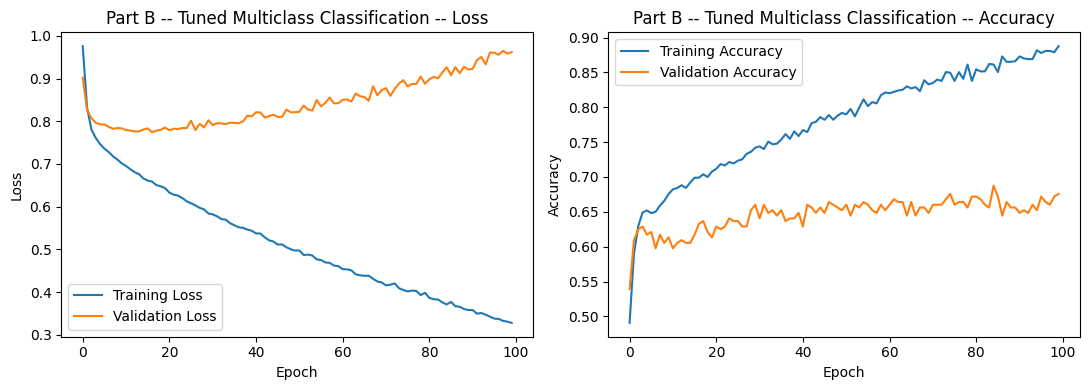

In [ ]:
# Train the model using the best hyperparameter configuration
history_tuned = tuned_model.fit(
    X3_train_scaled,
    y3_train,
    validation_split=0.2,
    epochs=100,
    batch_size=32,
    verbose=0
)

# Plot the tuned model's training and validation performanc
plot_history(
    history_tuned,
    "Part B -- Tuned Multiclass Classification",
    show_accuracy=True
)

In [ ]:
# Make predictions using the tuned model
tuned_probs = tuned_model.predict(X3_test_scaled)
tuned_preds = np.argmax(tuned_probs, axis=1)

# Calculate the tuned model's test accuracy
tuned_accuracy = accuracy_score(y3_test, tuned_preds)

# Compare the tuned model with the original baseline
print(f"Tuned Test Accuracy: {tuned_accuracy:.3f}")
print(f"Baseline Test Accuracy: {acc_multi:.3f}")
print(f"Improvement: {tuned_accuracy - acc_multi:.3f}")

10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
Tuned Test Accuracy: 0.681
Baseline Test Accuracy: 0.709
Improvement: -0.028


The best hyperparameter configuration found by Keras Tuner used 128 neurons in the first hidden layer, 64 neurons in the second hidden layer, and a learning rate of 0.001. The best validation accuracy during tuning was approximately 68.0%. After training the final tuned model, the test accuracy was 67.8%, compared to the baseline accuracy of 69.7%. This was a decrease of approximately 1.9 percentage points, so hyperparameter tuning alone did not improve the model's test performance.

### PART C

In [ ]:
# Build the tuned model again with Dropout to help reduce overfitting
regularized_model = tf.keras.Sequential([
    tf.keras.Input(shape=(X3_train_scaled.shape[1],)),

    tf.keras.layers.Dense(
        best_hp.get("units_1"),
        activation="relu"
    ),

    # Randomly disable 30% of neurons during training
    tf.keras.layers.Dropout(0.3),

    tf.keras.layers.Dense(
        best_hp.get("units_2"),
        activation="relu"
    ),

    # Apply Dropout again after the second hidden layer
    tf.keras.layers.Dropout(0.3),

    tf.keras.layers.Dense(
        n_classes,
        activation="softmax"
    )
])

# Compile using the learning rate selected during tuning
regularized_model.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=best_hp.get("learning_rate")
    ),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [ ]:
# Stop training when validation loss stops improving
early_stop = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=10,

    # Return to the model weights that produced the best validation loss
    restore_best_weights=True
)

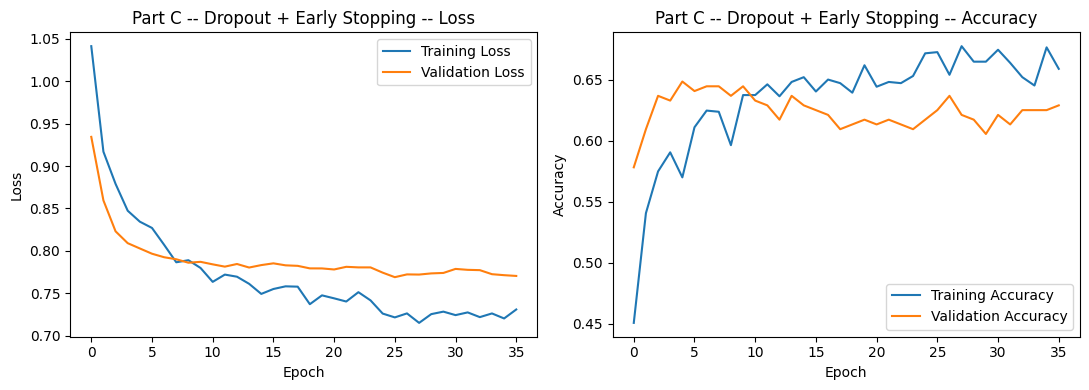

In [ ]:
# Train for up to 200 epochs while allowing Early Stopping to stop sooner
history_regularized = regularized_model.fit(
    X3_train_scaled,
    y3_train,
    validation_split=0.2,
    epochs=200,
    batch_size=32,
    callbacks=[early_stop],
    verbose=0
)

# Plot the new curves to see whether overfitting was reduced
plot_history(
    history_regularized,
    "Part C -- Dropout + Early Stopping",
    show_accuracy=True
)

In [ ]:
# Display when Early Stopping ended training
print("Epochs trained:", len(history_regularized.history["loss"]))

# Display the lowest validation loss reached during training
print(
    "Best validation loss:",
    min(history_regularized.history["val_loss"])
)

Epochs trained: 36
Best validation loss: 0.7689842581748962


10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
Regularized Test Accuracy: 0.669
Baseline Test Accuracy: 0.709
Tuned Test Accuracy: 0.681


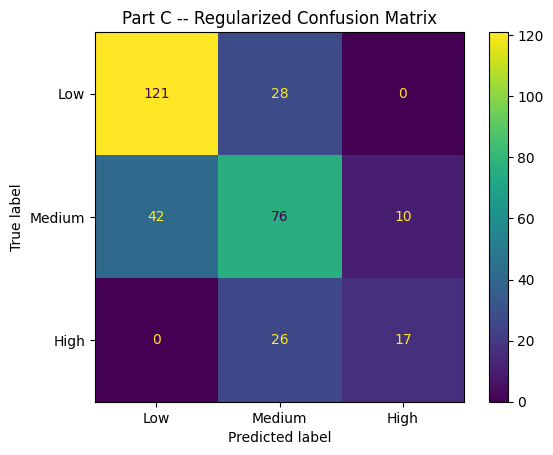

In [ ]:
# Make predictions using the regularized model
regularized_probs = regularized_model.predict(X3_test_scaled)
regularized_preds = np.argmax(regularized_probs, axis=1)

# Calculate the regularized model's test accuracy
regularized_accuracy = accuracy_score(y3_test, regularized_preds)

# Compare all three model results
print(f"Regularized Test Accuracy: {regularized_accuracy:.3f}")
print(f"Baseline Test Accuracy: {acc_multi:.3f}")
print(f"Tuned Test Accuracy: {tuned_accuracy:.3f}")

# Create the final confusion matrix
cm_regularized = confusion_matrix(y3_test, regularized_preds)

ConfusionMatrixDisplay(
    cm_regularized,
    display_labels=["Low", "Medium", "High"]
).plot()

plt.title("Part C -- Regularized Confusion Matrix")
plt.show()

After applying Dropout and Early Stopping, the gap between the training and validation curves became much smaller compared to the original model. Validation loss remained around 0.77 instead of continuing to increase while training loss decreased, showing that overfitting was reduced. Early Stopping ended training after 45 epochs, with a best validation loss of approximately 0.767. The final test accuracy was approximately 66.6%. The confusion matrix shows that the model still had the most difficulty distinguishing between neighboring classes, especially Medium with Low and High with Medium. Although the regularization techniques reduced overfitting, they did not improve the final test accuracy compared to the baseline model.

### PART D - REFLECTION

The test set should only be used after hyperparameter tuning is complete because it is meant to measure how well the final model performs on unseen data. If the test set is repeatedly used to select hyperparameters, the model could indirectly become tuned to the test data, making the final results less reliable. Dropout and Early Stopping helped reduce overfitting because the gap between training and validation performance became smaller, and validation loss stayed relatively stable instead of continuing to increase. Early Stopping also stopped training after 45 epochs instead of allowing the model to continue training for the full 200 epochs. Even though overfitting was reduced, the final test accuracy did not improve, so with unlimited time and computing resources I would test more hyperparameter combinations, different Dropout rates, and other model architectures to see if I could improve performance while still controlling overfitting.